# LSTM Multi-Sensor Forecasting — Improved

**Note on "accuracy":** this is a *regression* task (predicting continuous sensor values), so classification accuracy doesn't apply here. Keras won't compute it, and if you ever see `accuracy: 1.0000` on a regression model it's a bug, not a good sign. The regression equivalent of "accuracy" is **R²** (bounded, easy to read, higher = better) — added below as a custom metric so you get `r2` / `val_r2` printed every epoch right next to `loss` / `val_loss`, and plotted train-vs-validation after training.

Other changes made in this pass (see inline comments):
- Custom Keras `r2_keras` metric → train/val R² per epoch + curves
- `Huber` loss instead of raw MSE (more robust to the outlier-heavy sensor readings implied by your ~60% MAPE on `GA0151_A`)
- `recurrent_dropout` + `clipnorm` on the LSTM layers for better regularization/stability
- `ReduceLROnPlateau` so the LR backs off automatically when `val_loss` stalls, instead of relying on early stopping alone
- Loss/MAE/R² curves plotted (train vs val) right after training
- A results table + actual-vs-predicted plot at the end instead of only printed numbers
- Minor cleanup (removed a redundant reshape, used `Path` for the model file)

Outputs are cleared since I don't have your `feature_engineered.csv` to re-run it — re-run all cells top to bottom.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras import backend as K
import joblib
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [2]:
DATA_PATH = "../../dataset/processed/feature_engineered.csv"
SEQ_LENGTH = 24
FORECAST_HORIZON = 6
TRAIN_RATIO = 0.70
VAL_RATIO = 0.15
TEST_RATIO = 0.15
BATCH_SIZE = 64
EPOCH = 100
PATIENCE = 10          # early stopping patience
LR_PATIENCE = 5         # ReduceLROnPlateau patience
INITIAL_LR = 1e-3

In [3]:
df = pd.read_csv(DATA_PATH)

In [4]:
print("Dataset Shape:", df.shape)

Dataset Shape: (33476, 65)


In [5]:
df = df.select_dtypes(include=[np.number])

In [6]:
TARGET_COLUMNS = [
    "GA0151_A",
    "GA0151_C",
    "GA0151_D"
]

In [7]:
feature_columns = df.columns.tolist()
print("Number of features:", len(feature_columns))

Number of features: 65


In [8]:
# Chronological split — no shuffling, since this is time series (unchanged, this was already correct)
n = len(df)
train_end = int(n * TRAIN_RATIO)
val_end = int(n * (TRAIN_RATIO + VAL_RATIO))

train_df = df.iloc[:train_end].copy()
val_df = df.iloc[train_end:val_end].copy()
test_df = df.iloc[val_end:].copy()

print("Total samples :", len(df))
print("Training      :", len(train_df))
print("Validation    :", len(val_df))
print("Testing       :", len(test_df))

Total samples : 33476
Training      : 23433
Validation    : 5021
Testing       : 5022


In [9]:
# Fit scaler on TRAIN ONLY to avoid leakage (unchanged, this was already correct)
scaler = MinMaxScaler()
scaler.fit(train_df[feature_columns])
train_scaled = scaler.transform(train_df[feature_columns])
val_scaled = scaler.transform(val_df[feature_columns])
test_scaled = scaler.transform(test_df[feature_columns])

In [10]:
joblib.dump(scaler, "traffic_scaler.pkl")

['traffic_scaler.pkl']

In [11]:
def create_sequences(data, target_indices, seq_length, forecast_horizon):
    X = []
    y = []

    for i in range(seq_length, len(data) - forecast_horizon + 1):

        # Past 24 hours
        X.append(data[i - seq_length:i])

        # Next 6 hours for target sensors
        y.append(
            data[
                i:i + forecast_horizon,
                target_indices
            ]
        )

    return np.array(X), np.array(y)

In [12]:
target_indices = [
    feature_columns.index(col)
    for col in TARGET_COLUMNS
]

In [13]:
# Create training sequences
X_train, y_train = create_sequences(train_scaled, target_indices, SEQ_LENGTH, FORECAST_HORIZON)

# Create validation sequences
X_val, y_val = create_sequences(val_scaled, target_indices, SEQ_LENGTH, FORECAST_HORIZON)

# Create testing sequences
X_test, y_test = create_sequences(test_scaled, target_indices, SEQ_LENGTH, FORECAST_HORIZON)

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_val  :", X_val.shape)
print("y_val  :", y_val.shape)
print("X_test :", X_test.shape)
print("y_test :", y_test.shape)

X_train: (23404, 24, 65)
y_train: (23404, 6, 3)
X_val  : (4992, 24, 65)
y_val  : (4992, 6, 3)
X_test : (4993, 24, 65)
y_test : (4993, 6, 3)


In [14]:
# NOTE: previously this flattened y into (n, horizon*n_targets) for a plain Dense head.
# We now keep y as (n_samples, FORECAST_HORIZON, n_targets) because the model below is a
# proper seq2seq (encoder-decoder) that predicts the sequence directly, which preserves the
# temporal structure between the 6 forecasted hours instead of treating them as 18 independent
# flattened outputs.
print("y_train:", y_train.shape)
print("y_val  :", y_val.shape)
print("y_test :", y_test.shape)


y_train: (23404, 6, 3)
y_val  : (4992, 6, 3)
y_test : (4993, 6, 3)


## Custom R² metric (the "accuracy" for regression)

R² is bounded (≤ 1, higher is better, 0 ≈ "no better than predicting the mean") so it reads like an accuracy score during training. Keras metrics must be differentiable ops on tensors, so this is implemented with `keras.backend` rather than `sklearn.r2_score` (which only works on numpy arrays after training).

## Architecture upgrade: encoder–decoder (seq2seq) + Bidirectional LSTM + per-sensor loss weighting

Changes from the previous version, and why:

- **Seq2seq (encoder → `RepeatVector` → decoder → `TimeDistributed(Dense)`)** instead of a flattened `Dense(horizon * n_targets)` head. The old head treated the 6 forecasted hours as 18 unrelated numbers; the decoder LSTM instead unrolls step-by-step, so hour *t+2*'s prediction is conditioned on the (implicit) trajectory up to *t+1*, not just the encoder's summary vector alone.
- **`Bidirectional` LSTM in the encoder.** The encoder only ever looks at a *fixed, already-observed* 24-hour window, so unlike the decoder there's no future-leakage risk from reading it in both directions — it just gives the encoder more context per timestep (e.g. a dip surrounded by rising values on both sides reads differently than a dip at the start of a rise). The decoder stays a plain (forward-only) LSTM since it's autoregressively producing the future.
- **Per-sensor weighted loss.** `GA0151_A` had the weakest fit (R² ≈ 0.64, MAPE ≈ 60%) in the previous run. With a single scalar Huber loss, the optimizer implicitly weights sensors by the *magnitude* of their errors, so a well-behaved sensor with tiny absolute errors already near-zero won't get much gradient signal to improve further, while whichever sensor has the largest raw errors dominates the update — not necessarily the one that most needs it. `weighted_huber` below lets you explicitly upweight `GA0151_A` so it gets a fair share of gradient signal instead of being drowned out.


In [15]:
def r2_keras(y_true, y_pred):
    ss_res = K.sum(K.square(y_true - y_pred))
    ss_tot = K.sum(K.square(y_true - K.mean(y_true)))
    return 1 - ss_res / (ss_tot + K.epsilon())

# Per-sensor weights for the loss (order must match TARGET_COLUMNS).
# GA0151_A was the weakest performer previously, so it gets more weight;
# tune these based on your own results rather than trusting the defaults blindly.
TARGET_LOSS_WEIGHTS = [2.0, 1.0, 1.0]   # [GA0151_A, GA0151_C, GA0151_D]
_weights_tensor = tf.constant(TARGET_LOSS_WEIGHTS, dtype=tf.float32)

def weighted_huber(y_true, y_pred, delta=1.0):
    error = y_true - y_pred
    abs_error = K.abs(error)
    quadratic = K.minimum(abs_error, delta)
    linear = abs_error - quadratic
    per_element_loss = 0.5 * K.square(quadratic) + delta * linear
    # per_element_loss shape: (batch, horizon, n_targets) -> weight the last axis
    weighted = per_element_loss * _weights_tensor
    return K.mean(weighted)


In [16]:
from tensorflow.keras.layers import Bidirectional, RepeatVector, TimeDistributed
from tensorflow.keras.models import Model

n_targets = len(TARGET_COLUMNS)

encoder_inputs = Input(shape=(SEQ_LENGTH, len(feature_columns)), name="encoder_input")

# Encoder: reads the observed 24h window in both directions for richer context per timestep
x = Bidirectional(LSTM(128, return_sequences=True, recurrent_dropout=0.1))(encoder_inputs)
x = Dropout(0.2)(x)
# return_sequences=False on the final encoder layer collapses to a single context vector
encoder_out = Bidirectional(LSTM(64, return_sequences=False, recurrent_dropout=0.1))(x)
encoder_out = Dropout(0.2)(encoder_out)

# Bridge: repeat the context vector once per forecast step so the decoder has a starting
# point at every timestep it needs to produce
decoder_input = RepeatVector(FORECAST_HORIZON)(encoder_out)

# Decoder: forward-only (autoregressive in spirit) LSTM unrolling across the 6 forecast hours
decoder_out = LSTM(64, return_sequences=True, recurrent_dropout=0.1)(decoder_input)
decoder_out = Dropout(0.2)(decoder_out)
decoder_out = TimeDistributed(Dense(32, activation="relu"))(decoder_out)
outputs = TimeDistributed(Dense(n_targets))(decoder_out)  # (batch, horizon, n_targets)

model = Model(encoder_inputs, outputs, name="lstm_seq2seq_forecaster")


In [17]:
model.compile(
    # clipnorm guards against exploding gradients, which recurrent_dropout + LSTMs can be prone to
    optimizer=Adam(learning_rate=INITIAL_LR, clipnorm=1.0),
    # Weighted Huber: robust to outlier spikes (like plain Huber), and additionally gives
    # GA0151_A more gradient weight since it was the weakest-fitting sensor previously
    loss=weighted_huber,
    metrics=["mae", r2_keras]
)

model.summary()


Model: "lstm_seq2seq_forecaster"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ encoder_input (InputLayer)      │ (None, 24, 65)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 24, 256)        │       198,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 128)            │       164,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector (RepeatVector)    │ (None, 6, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 6, 64)          │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 6, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ (None, 6, 32)          │         2,080 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_1              │ (None, 6, 3)           │            99 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 414,595 (1.58 MB)

 Trainable params: 414,595 (1.58 MB)

 Non-trainable params: 0 (0.00 B)

In [18]:
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=PATIENCE,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    "lstm_model.keras",
    monitor="val_loss",
    save_best_only=True,
    mode="min"
)

# Backs the learning rate off when val_loss plateaus, instead of only stopping outright
reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=LR_PATIENCE,
    min_lr=1e-6,
    verbose=1
)

In [19]:
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCH,
    batch_size=BATCH_SIZE,
    callbacks=[early_stopping, checkpoint, reduce_lr],
    verbose=1
)

Epoch 1/100
366/366 ━━━━━━━━━━━━━━━━━━━━ 37s 72ms/step - loss: 0.0061 - mae: 0.0706 - r2_keras: 0.6796 - val_loss: 0.0049 - val_mae: 0.0614 - val_r2_keras: 0.7994 - learning_rate: 0.0010
Epoch 2/100
366/366 ━━━━━━━━━━━━━━━━━━━━ 26s 71ms/step - loss: 0.0035 - mae: 0.0526 - r2_keras: 0.8190 - val_loss: 0.0045 - val_mae: 0.0592 - val_r2_keras: 0.8179 - learning_rate: 0.0010
Epoch 3/100
366/366 ━━━━━━━━━━━━━━━━━━━━ 26s 70ms/step - loss: 0.0030 - mae: 0.0488 - r2_keras: 0.8412 - val_loss: 0.0043 - val_mae: 0.0570 - val_r2_keras: 0.8234 - learning_rate: 0.0010
Epoch 4/100
366/366 ━━━━━━━━━━━━━━━━━━━━ 26s 70ms/step - loss: 0.0028 - mae: 0.0460 - r2_keras: 0.8559 - val_loss: 0.0043 - val_mae: 0.0575 - val_r2_keras: 0.8223 - learning_rate: 0.0010
Epoch 5/100
366/366 ━━━━━━━━━━━━━━━━━━━━ 32s 87ms/step - loss: 0.0026 - mae: 0.0445 - r2_keras: 0.8642 - val_loss: 0.0045 - val_mae: 0.0588 - val_r2_keras: 0.8117 - learning_rate: 0.0010
Epoch 6/100
366/366 ━━━━━━━━━━━━━━━━━━━━ 31s 86ms/step - loss: 0.

## Training curves: loss, MAE, and R² (train vs. validation)

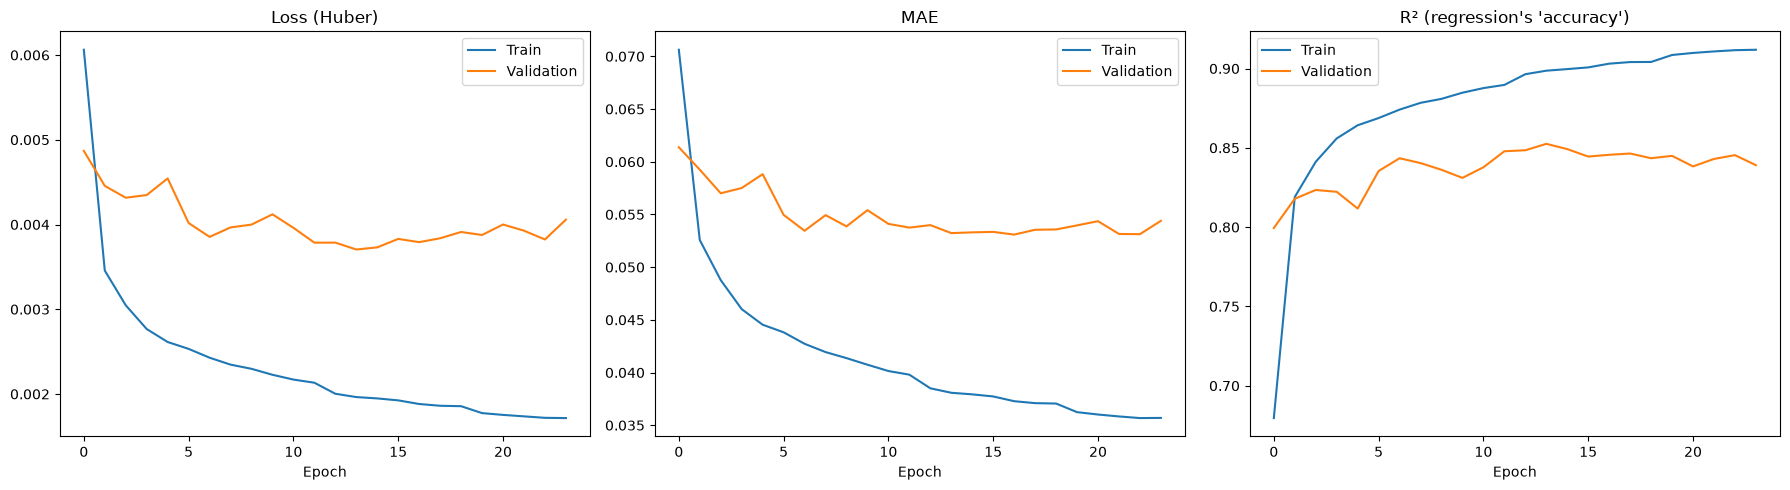

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(history.history["loss"], label="Train")
axes[0].plot(history.history["val_loss"], label="Validation")
axes[0].set_title("Loss (Huber)")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(history.history["mae"], label="Train")
axes[1].plot(history.history["val_mae"], label="Validation")
axes[1].set_title("MAE")
axes[1].set_xlabel("Epoch")
axes[1].legend()

axes[2].plot(history.history["r2_keras"], label="Train")
axes[2].plot(history.history["val_r2_keras"], label="Validation")
axes[2].set_title("R² (regression's 'accuracy')")
axes[2].set_xlabel("Epoch")
axes[2].legend()

plt.tight_layout()
plt.show()

In [21]:
test_loss, test_mae, test_r2 = model.evaluate(X_test, y_test, verbose=1)

print("\nTest Loss (Huber):", test_loss)
print("Test MAE:", test_mae)
print("Test R\u00b2:", test_r2)

157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 0.0047 - mae: 0.0630 - r2_keras: 0.8350

Test Loss (Huber): 0.00469687907025218
Test MAE: 0.06298097223043442
Test R²: 0.8349802494049072


In [22]:
y_pred = model.predict(X_test)
print("\nPrediction shape (already seq2seq, no flatten/reshape needed):")
print("y_pred:", y_pred.shape)
print("y_test:", y_test.shape)


157/157 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step

Prediction shape (already seq2seq, no flatten/reshape needed):
y_pred: (4993, 6, 3)
y_test: (4993, 6, 3)


In [23]:
y_pred_seq = y_pred                 # (n_samples, FORECAST_HORIZON, n_targets)
y_test_seq = y_test                 # already (n_samples, FORECAST_HORIZON, n_targets)

print("\nFinal shapes:")
print("y_pred:", y_pred_seq.shape)
print("y_test:", y_test_seq.shape)



Final shapes:
y_pred: (4993, 6, 3)
y_test: (4993, 6, 3)


In [24]:
num_features = len(feature_columns)

y_pred_original = np.zeros((y_pred_seq.shape[0], FORECAST_HORIZON, num_features))
y_test_original_scaled = np.zeros((y_test_seq.shape[0], FORECAST_HORIZON, num_features))

for j, target_idx in enumerate(target_indices):
    y_pred_original[:, :, target_idx] = y_pred_seq[:, :, j]
    y_test_original_scaled[:, :, target_idx] = y_test_seq[:, :, j]

# Inverse scaling
y_pred_original = scaler.inverse_transform(
    y_pred_original.reshape(-1, num_features)
).reshape(-1, FORECAST_HORIZON, num_features)

y_test_original = scaler.inverse_transform(
    y_test_original_scaled.reshape(-1, num_features)
).reshape(-1, FORECAST_HORIZON, num_features)

y_pred_original = y_pred_original[:, :, target_indices]
y_test_original = y_test_original[:, :, target_indices]

print("\nOriginal-scale shapes:")
print("Predictions:", y_pred_original.shape)
print("Actual     :", y_test_original.shape)



Original-scale shapes:
Predictions: (4993, 6, 3)
Actual     : (4993, 6, 3)


## Per-sensor metrics (as a table, and plotted)

In [25]:
results = []

for i, sensor in enumerate(TARGET_COLUMNS):
    actual = y_test_original[:, :, i].flatten()
    predicted = y_pred_original[:, :, i].flatten()

    mae = mean_absolute_error(actual, predicted)
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    r2 = r2_score(actual, predicted)

    mask = actual != 0
    mape = np.mean(np.abs((actual[mask] - predicted[mask]) / actual[mask])) * 100

    results.append({"Sensor": sensor, "MAE": mae, "RMSE": rmse, "MAPE (%)": mape, "R2": r2})

results_df = pd.DataFrame(results).set_index("Sensor")
results_df

,MAE,RMSE,MAPE (%),R2
Sensor,,,,
GA0151_A,10.476994,15.890681,69.010314,0.623427
GA0151_C,25.188055,34.391688,21.280495,0.793236
GA0151_D,21.948239,30.100311,31.318503,0.745953


## Naive persistence baseline

A model is only as good as what it beats. The simplest possible forecast is "the next 6 hours will equal the last observed value" (persistence / random-walk baseline). If the LSTM doesn't clearly beat this, the extra complexity isn't earning its keep. This also gives an intuitive sense of scale for the MAE/RMSE numbers above.


In [26]:
# Persistence baseline: repeat the last observed value (at the end of each 24h input window)
# across all FORECAST_HORIZON steps, for each target sensor.
last_observed_scaled = X_test[:, -1, target_indices]                     # (n_samples, n_targets), still scaled
last_observed_full = np.zeros((last_observed_scaled.shape[0], num_features))
last_observed_full[:, target_indices] = last_observed_scaled
last_observed_original = scaler.inverse_transform(last_observed_full)[:, target_indices]  # (n_samples, n_targets)

baseline_results = []
for i, sensor in enumerate(TARGET_COLUMNS):
    actual = y_test_original[:, :, i]                                     # (n_samples, horizon)
    persistence_pred = np.repeat(last_observed_original[:, i:i+1], FORECAST_HORIZON, axis=1)

    mae = mean_absolute_error(actual.flatten(), persistence_pred.flatten())
    rmse = np.sqrt(mean_squared_error(actual.flatten(), persistence_pred.flatten()))
    r2 = r2_score(actual.flatten(), persistence_pred.flatten())

    baseline_results.append({"Sensor": sensor, "Baseline MAE": mae, "Baseline RMSE": rmse, "Baseline R2": r2})

baseline_df = pd.DataFrame(baseline_results).set_index("Sensor")
comparison_df = results_df.join(baseline_df)
comparison_df["MAE improvement vs baseline (%)"] = (
    (comparison_df["Baseline MAE"] - comparison_df["MAE"]) / comparison_df["Baseline MAE"] * 100
)
comparison_df


,MAE,RMSE,MAPE (%),R2,Baseline MAE,Baseline RMSE,Baseline R2,MAE improvement vs baseline (%)
Sensor,,,,,,,,
GA0151_A,10.476994,15.890681,69.010314,0.623427,19.664530,26.385032,-0.038195,46.721363
GA0151_C,25.188055,34.391688,21.280495,0.793236,62.514888,86.290060,-0.301637,59.708709
GA0151_D,21.948239,30.100311,31.318503,0.745953,46.247981,60.744752,-0.034640,52.542275


## Per-horizon-step metrics

Aggregate MAE/R² above blend all 6 forecast steps together, which hides an important pattern: error almost always grows the further out you forecast (1-hour-ahead is easier than 6-hours-ahead). Breaking it down by step tells you how much you can trust the far end of the forecast, and whether `FORECAST_HORIZON` is set sensibly for your use case.


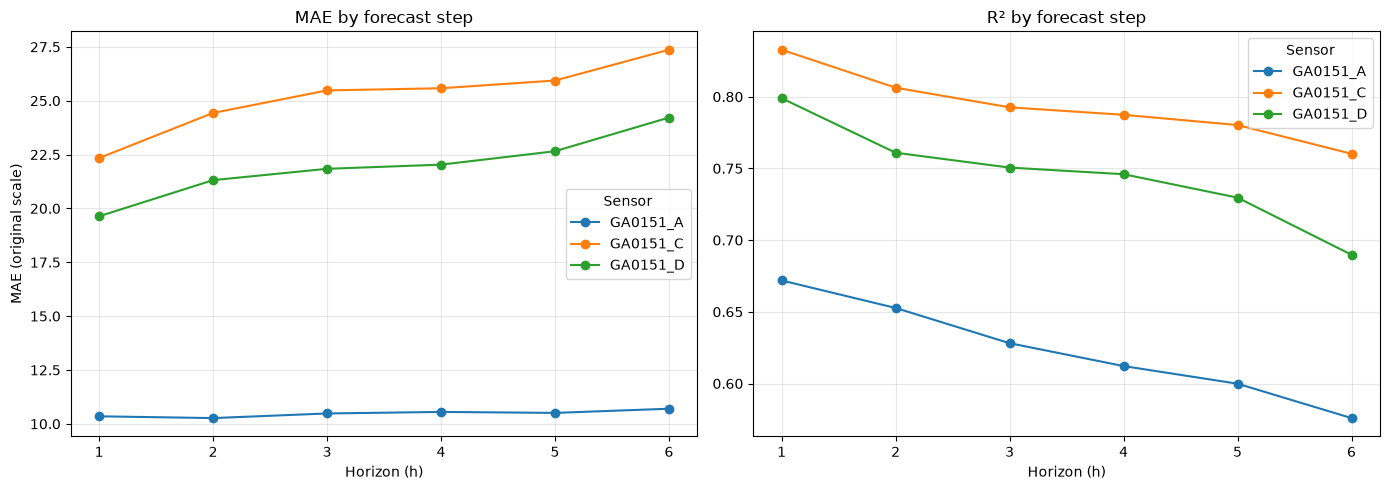

Sensor,GA0151_A,GA0151_C,GA0151_D
Horizon (h),,,
1,10.349266,22.337910,19.634509
2,10.267568,24.432707,21.312789
3,10.481564,25.477490,21.838564
4,10.553531,25.578156,22.031678
5,10.508455,25.936889,22.654566
6,10.701577,27.365178,24.217330


In [27]:
step_results = []
for i, sensor in enumerate(TARGET_COLUMNS):
    for h in range(FORECAST_HORIZON):
        actual = y_test_original[:, h, i]
        predicted = y_pred_original[:, h, i]
        mae = mean_absolute_error(actual, predicted)
        r2 = r2_score(actual, predicted)
        step_results.append({"Sensor": sensor, "Horizon (h)": h + 1, "MAE": mae, "R2": r2})

step_df = pd.DataFrame(step_results)
pivot_mae = step_df.pivot(index="Horizon (h)", columns="Sensor", values="MAE")
pivot_r2 = step_df.pivot(index="Horizon (h)", columns="Sensor", values="R2")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
pivot_mae.plot(marker="o", ax=axes[0])
axes[0].set_title("MAE by forecast step")
axes[0].set_ylabel("MAE (original scale)")
axes[0].grid(alpha=0.3)

pivot_r2.plot(marker="o", ax=axes[1])
axes[1].set_title("R² by forecast step")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

pivot_mae


`GA0151_A` had the weakest fit last run (R² ≈ 0.64, MAPE ≈ 60%) compared to the other two sensors. That's usually a sign that sensor's values sit closer to zero (so MAPE explodes on small denominators) and/or it's noisier — worth checking its distribution separately rather than assuming the model is failing across the board.

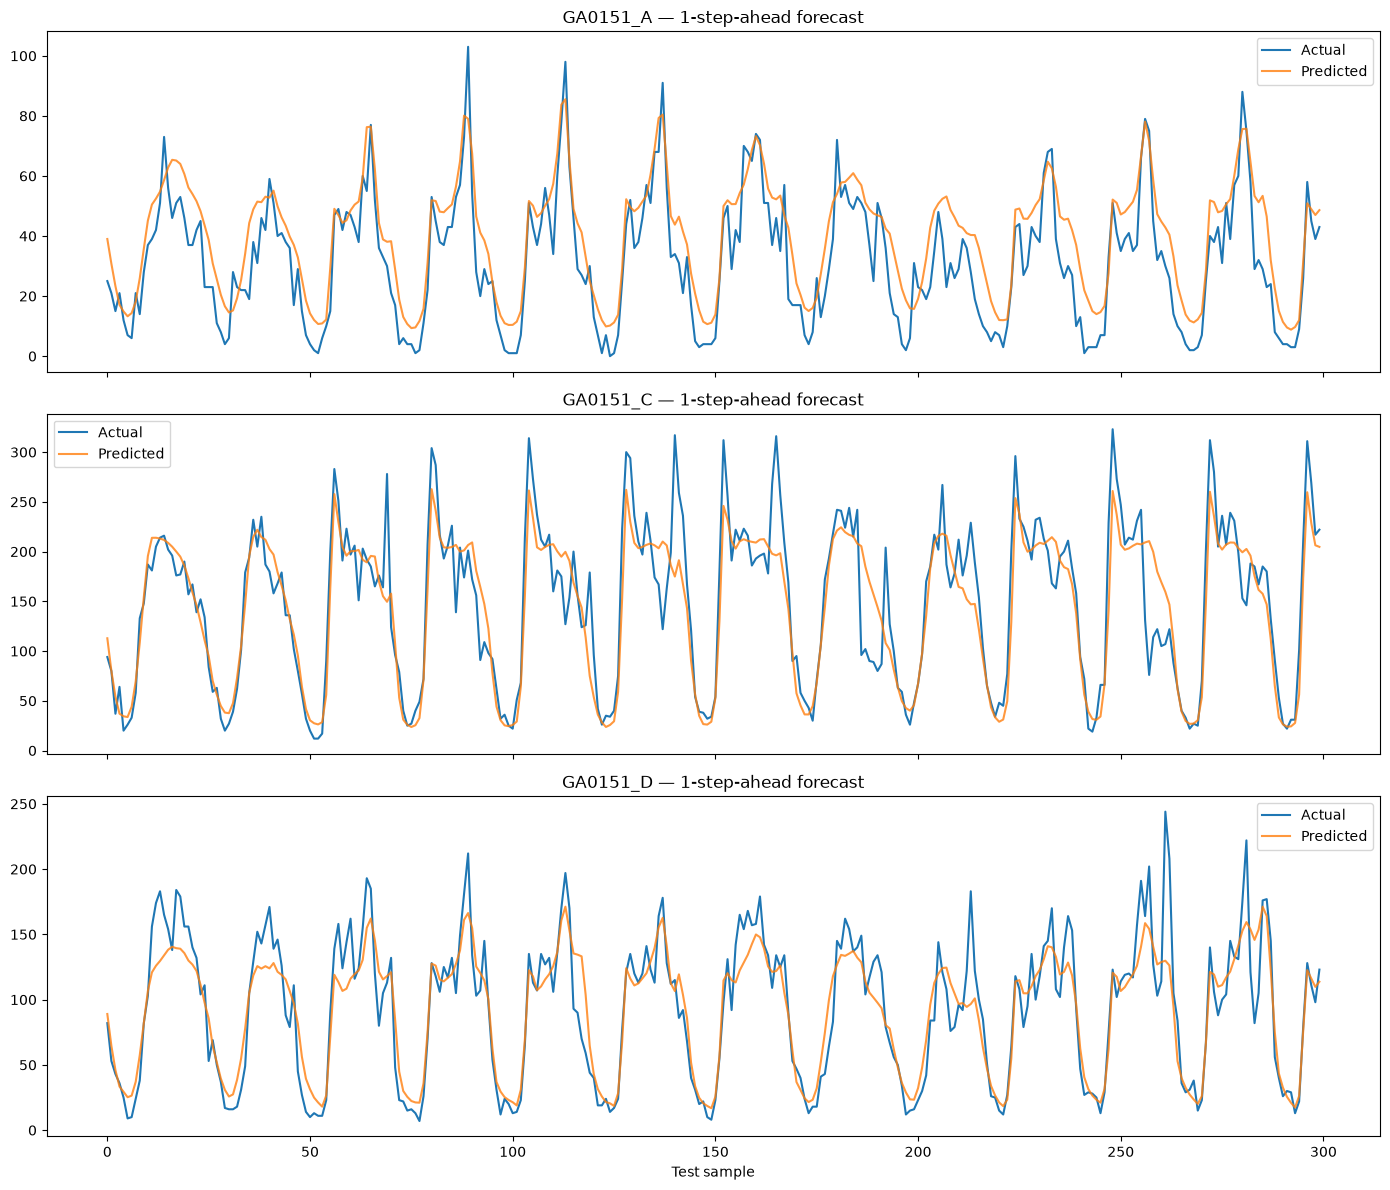

In [28]:
# Actual vs. predicted for the first forecast step of each sensor, over a slice of the test set
fig, axes = plt.subplots(len(TARGET_COLUMNS), 1, figsize=(14, 4 * len(TARGET_COLUMNS)), sharex=True)
window = slice(0, 300)  # first 300 test sequences

for i, sensor in enumerate(TARGET_COLUMNS):
    ax = axes[i]
    ax.plot(y_test_original[window, 0, i], label="Actual", linewidth=1.5)
    ax.plot(y_pred_original[window, 0, i], label="Predicted", linewidth=1.5, alpha=0.8)
    ax.set_title(f"{sensor} — 1-step-ahead forecast")
    ax.legend()

plt.xlabel("Test sample")
plt.tight_layout()
plt.show()